In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Netflix_data.csv")
print("DataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
df.describe()
display(df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Descriptive Statistics:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
count_type = df['type'].value_counts()
print(count_type)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


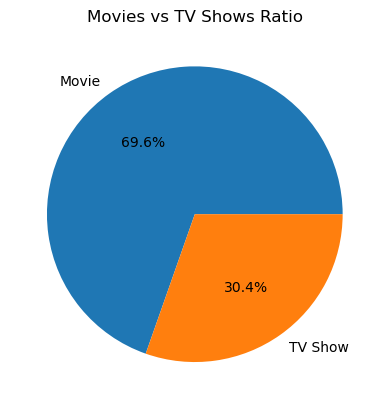

In [4]:
type_count = df['type'].value_counts()

plt.figure()
type_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Movies vs TV Shows Ratio')
plt.ylabel('')
plt.show()

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


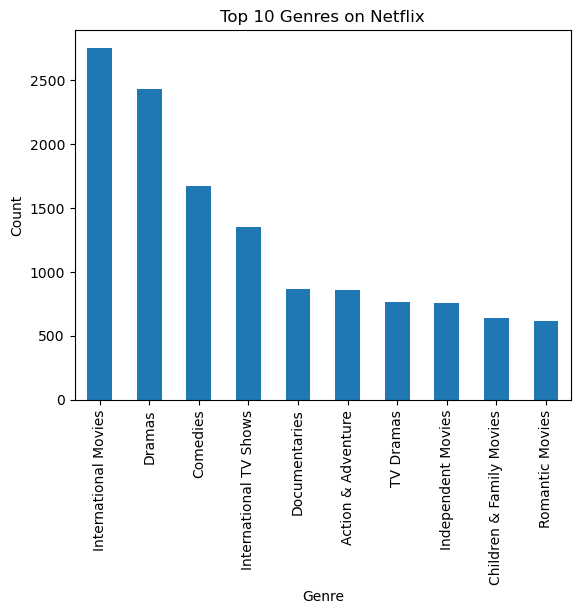

In [5]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
genre_count = genres.value_counts().head(10)
print(genre_count)
plt.figure()
genre_count.plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


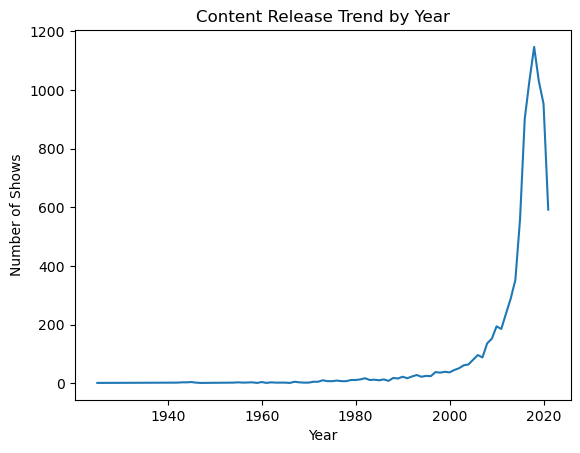

In [6]:
year_count = df['release_year'].value_counts().sort_index()
print(year_count.tail())  # latest years
plt.figure()
year_count.plot()
plt.title('Content Release Trend by Year')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.show()

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


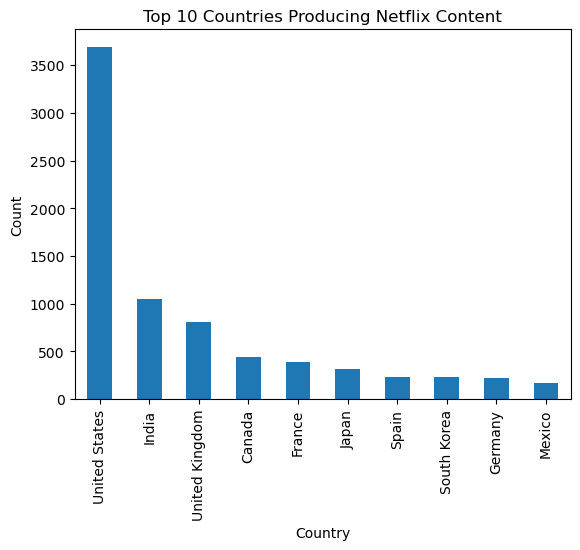

In [7]:
countries = df['country'].dropna().str.split(', ', expand=True).stack()
country_count = countries.value_counts().head(10)
print(country_count)
plt.figure()
country_count.plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


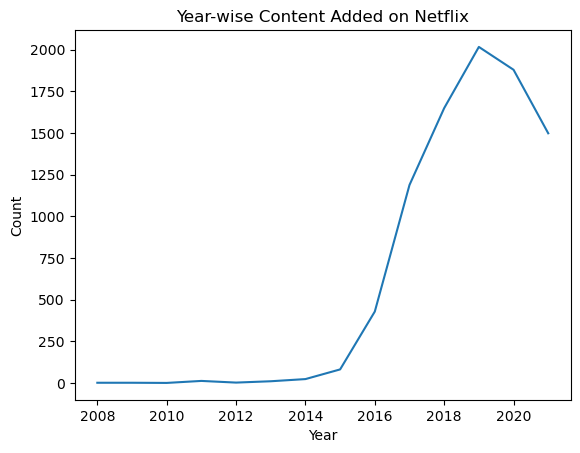

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
year_added_count = df['year_added'].value_counts().sort_index()
print(year_added_count)
plt.figure()
year_added_count.plot()
plt.title('Year-wise Content Added on Netflix')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


<Axes: title={'center': 'Most Frequent Ratings'}, xlabel='rating'>

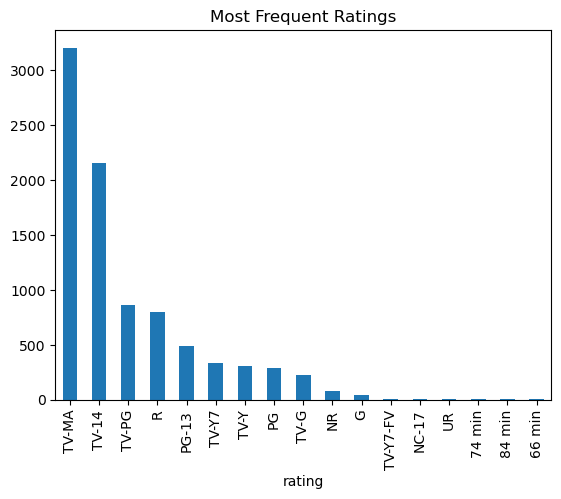

In [9]:
rating_counts = df['rating'].value_counts()
print(rating_counts.head(5))
rating_counts.plot(kind='bar', title='Most Frequent Ratings')

country
United States     928
India             248
United Kingdom    177
Spain             119
Japan              87
South Korea        85
France             80
Mexico             77
Turkey             63
Canada             61
Name: count, dtype: int64


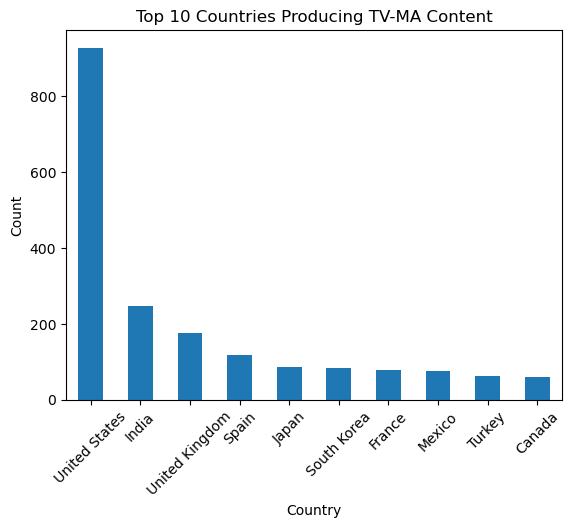

In [23]:
mature_content = df[df['rating'] == 'TV-MA']
mature_countries = mature_content['country'].value_counts().head(10)
print(mature_countries)
plt.figure()
mature_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing TV-MA Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [10]:
genre_comparison = df.groupby(['type', 'listed_in']).size().reset_index(name='count')
print(genre_comparison.sort_values(by='count', ascending=False).groupby('type').head(5))

        type                                          listed_in  count
217    Movie                       Dramas, International Movies    362
183    Movie                                      Documentaries    359
276    Movie                                    Stand-Up Comedy    334
142    Movie             Comedies, Dramas, International Movies    274
210    Movie   Dramas, Independent Movies, International Movies    252
433  TV Show                                           Kids' TV    220
423  TV Show                  International TV Shows, TV Dramas    121
346  TV Show  Crime TV Shows, International TV Shows, TV Dramas    110
444  TV Show                              Kids' TV, TV Comedies     99
452  TV Show                                         Reality TV     95


In [11]:
us_genres = df[df['country'] == 'United States']['listed_in'].value_counts().head(5)
non_us_genres = df[df['country'] != 'United States']['listed_in'].value_counts().head(5)

print("Top US Genres:\n", us_genres)
print("\nTop International Genres:\n", non_us_genres)

Top US Genres:
 listed_in
Documentaries                         249
Stand-Up Comedy                       209
Children & Family Movies, Comedies     90
Dramas                                 88
Comedies                               84
Name: count, dtype: int64

Top International Genres:
 listed_in
Dramas, International Movies                        361
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Dramas, International Movies, Romantic Movies       179
Documentaries, International Movies                 178
Name: count, dtype: int64


listed_in
International Movies        662
International TV Shows      564
Dramas                      530
Comedies                    362
TV Dramas                   343
TV Comedies                 252
Documentaries               234
Crime TV Shows              226
Children & Family Movies    205
Docuseries                  178
Name: count, dtype: int64


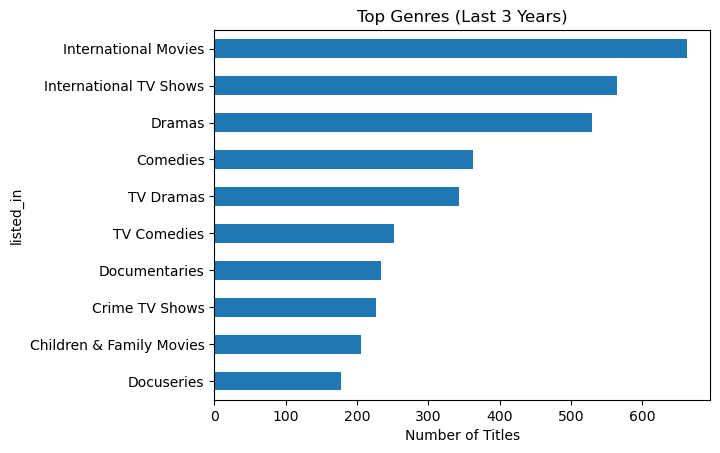

In [12]:
recent_df = df[df['release_year'] >= 2019]
popular_recent_genres = (recent_df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10))
print(popular_recent_genres)
plt.figure()
popular_recent_genres.sort_values().plot(kind='barh')
plt.title('Top Genres (Last 3 Years)')
plt.xlabel('Number of Titles')
plt.show()

In [13]:
top_directors = df.assign(director_list=df['director'].str.split(',')) \
                  .explode('director_list')['director_list'] \
                  .dropna() \
                  .value_counts() \
                  .head(10)

print(top_directors)

director_list
Rajiv Chilaka          22
RaÃºl Campos           18
 Jan Suter             18
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: count, dtype: int64


cast_list
 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
 Rajesh Kava         26
Shah Rukh Khan       26
 Yuki Kaji           25
 Paresh Rawal        25
 Andrea Libman       25
Name: count, dtype: int64


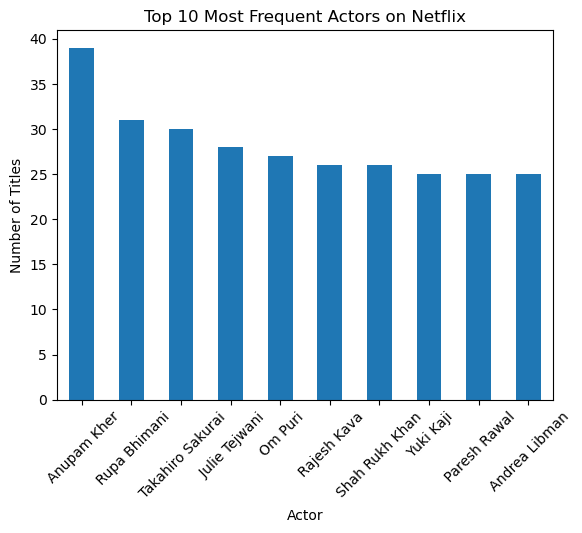

In [14]:
top_actors = df.assign(cast_list=df['cast'].str.split(',')) \
               .explode('cast_list')['cast_list'] \
               .dropna() \
               .value_counts() \
               .head(10)

print(top_actors)
plt.figure()
top_actors.plot(kind='bar')

plt.title('Top 10 Most Frequent Actors on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

director_list        listed_in               
Rajiv Chilaka        Children & Family Movies    22
 Jan Suter           Stand-Up Comedy             18
RaÃºl Campos         Stand-Up Comedy             18
Suhas Kadav          Children & Family Movies    16
Marcus Raboy         Stand-Up Comedy             15
Jay Karas            Stand-Up Comedy             14
Cathy Garcia-Molina   International Movies       11
Jay Chapman          Stand-Up Comedy             11
Youssef Chahine       International Movies       10
Shannon Hartman      Stand-Up Comedy              9
dtype: int64


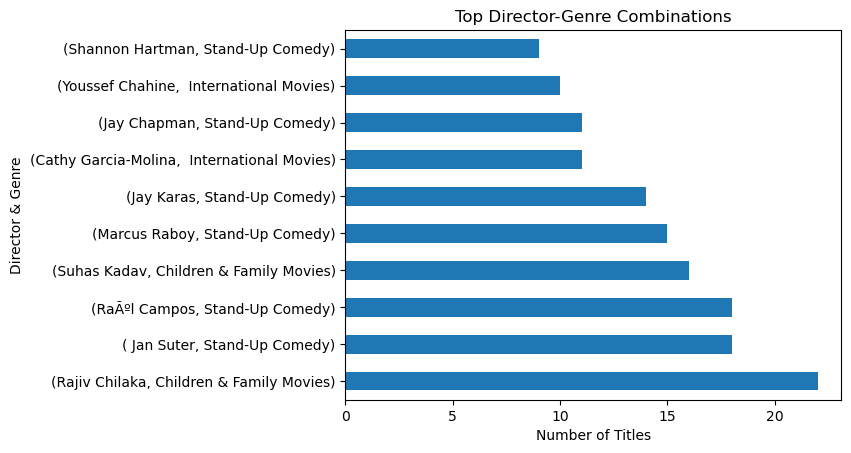

In [15]:
dir_genre = df.assign(
    director_list=df['director'].str.split(','),
    listed_in=df['listed_in'].str.split(',')
).explode('director_list').explode('listed_in')

top_pairs = dir_genre.groupby(['director_list', 'listed_in']) \
                    .size() \
                    .sort_values(ascending=False) \
                    .head(10)

print(top_pairs)

top_pairs.plot(kind='barh')

plt.title('Top Director-Genre Combinations')
plt.xlabel('Number of Titles')
plt.ylabel('Director & Genre')

plt.show()

Titles with missing director or cast: 3107


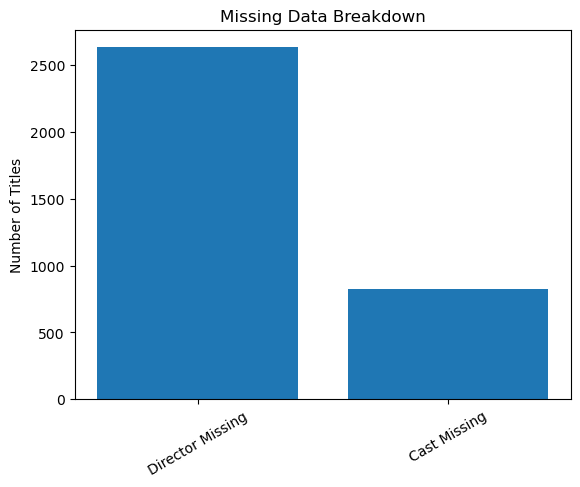

In [16]:
unknown_data = df[(df['director'].isna()) | (df['cast'].isna())].shape[0]

print(f"Titles with missing director or cast: {unknown_data}")

missing_data = {
    'Director Missing': df['director'].isna().sum(),
    'Cast Missing': df['cast'].isna().sum()
}

plt.figure()
plt.bar(missing_data.keys(), missing_data.values())

plt.title('Missing Data Breakdown')
plt.ylabel('Number of Titles')
plt.xticks(rotation=30)

plt.show()

production_type
Produced    5691
Acquired     440
Name: count, dtype: int64


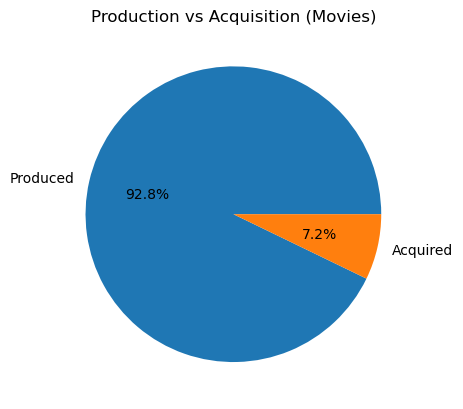

In [17]:
movies = df[df['type'] == 'Movie'].copy()
movies['production_type'] = movies['country'].apply(
    lambda x: 'Acquired' if pd.isna(x) else 'Produced'
)
prod_counts = movies['production_type'].value_counts()
print(prod_counts)
plt.figure()
prod_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Production vs Acquisition (Movies)')
plt.ylabel('')
plt.show()

Most common TV show length: 1 Season (1793 shows)


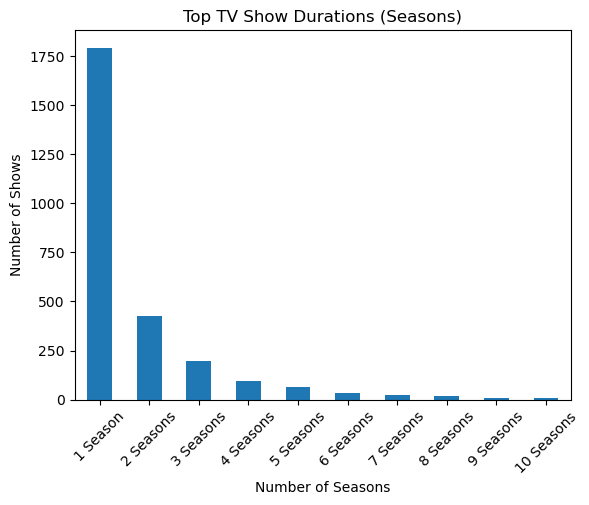

In [18]:
vc = df[df['type'] == 'TV Show']['duration'].value_counts().head(10)
print(f"Most common TV show length: {vc.idxmax()} ({vc.max()} shows)")

plt.figure()
vc.plot(kind='bar')

plt.title('Top TV Show Durations (Seasons)')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Shows')
plt.xticks(rotation=45)

plt.show()

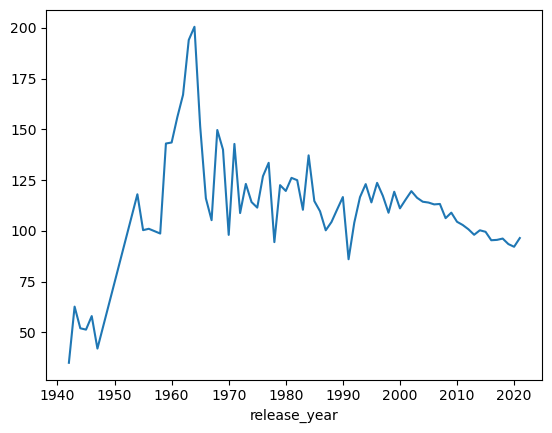

In [19]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = pd.to_numeric(
    movies['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

duration_trend = movies.groupby('release_year')['duration_min'].mean()

duration_trend.plot(kind='line')
plt.show()

<Figure size 1200x600 with 0 Axes>

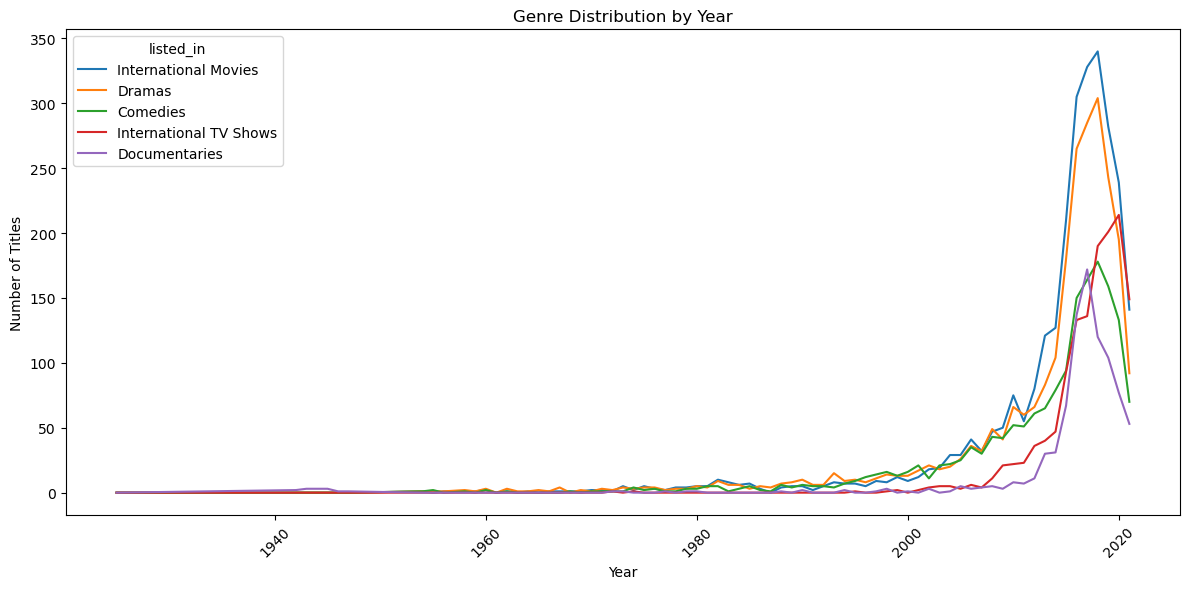

In [20]:
df_genre = df.copy()
df_genre['listed_in'] = df_genre['listed_in'].str.split(',')
df_genre = df_genre.explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()
genre_year = df_genre.groupby(['release_year', 'listed_in']).size().reset_index(name='count')
pivot = genre_year.pivot(index='release_year', columns='listed_in', values='count').fillna(0)
pivot = pivot.sort_index()
top_genres = df_genre['listed_in'].value_counts().head(5).index
pivot = pivot[top_genres]
plt.figure(figsize=(12, 6))
pivot.plot(kind='line', figsize=(12,6))

plt.title('Genre Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

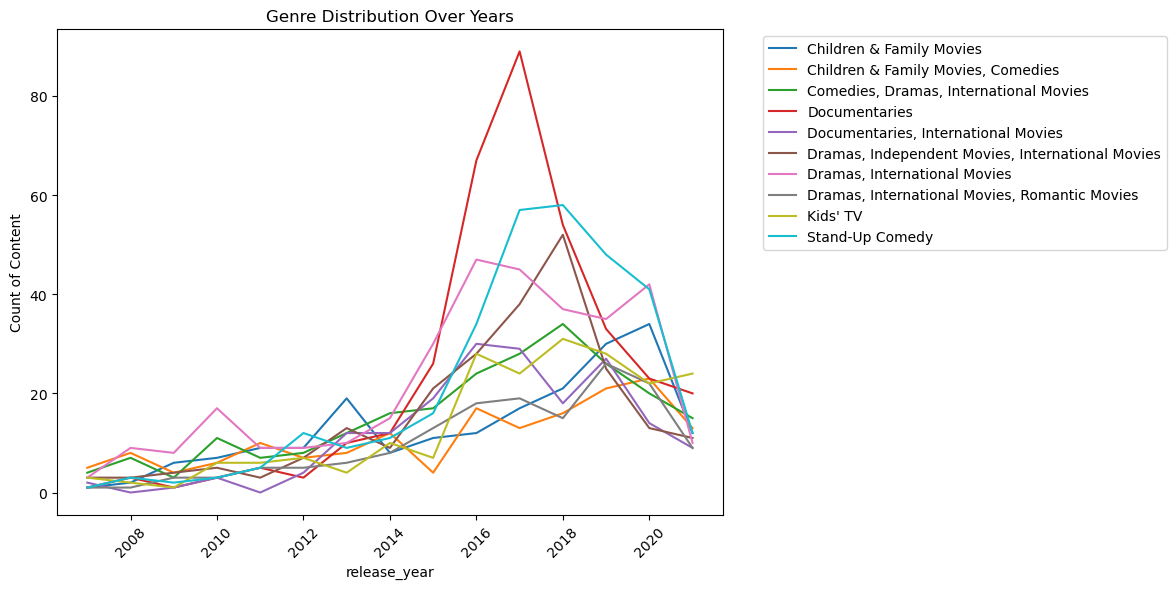

In [21]:
top_genres = df['listed_in'].value_counts().nlargest(10).index
df_filtered = df[df['listed_in'].isin(top_genres)]
genre_trend = df_filtered.groupby(['release_year', 'listed_in']).size().unstack(fill_value=0)
genre_trend.tail(15).plot(kind='line', figsize=(12, 6))
plt.title('Genre Distribution Over Years')
plt.ylabel('Count of Content')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
df_exploded = df.assign(country=df['country'].str.split(', ')).explode('country')
df_exploded = df_exploded.assign(listed_in=df_exploded['listed_in'].str.split(', ')).explode('listed_in')
top_countries_per_genre = df_exploded.groupby(['listed_in', 'country']).size().reset_index(name='count')
top_countries_per_genre = top_countries_per_genre.loc[top_countries_per_genre.groupby('listed_in')['count'].idxmax()]
print(top_countries_per_genre.sort_values('count', ascending=False))

                         listed_in         country  count
667           International Movies           India    864
489                         Dramas   United States    835
225                       Comedies   United States    680
362                  Documentaries   United States    511
57              Action & Adventure   United States    404
628             Independent Movies   United States    390
135       Children & Family Movies   United States    390
1418                     Thrillers   United States    292
1207                   TV Comedies   United States    258
1267                     TV Dramas   United States    232
970                Romantic Movies   United States    225
87                British TV Shows  United Kingdom    225
1129               Stand-Up Comedy   United States    216
824                       Kids' TV   United States    214
560                  Horror Movies   United States    201
395                     Docuseries   United States    192
1047          